# Llama-3.1-70B — Spot Tolerance Analysis (Scenario A)

Llama-3.1-70B-Instruct, 2 pipelines (SS-P1: 6 stages on g6.12xlarge + g6e.xlarge, SS-P2: 3 stages on g5.12xlarge + g6.12xlarge)

**Duration**: 60 minutes | **Benchmark**: offline (saturated) + online (Poisson arrival)

**Events** (Scenario A):

| Time | Type | Instances |
|------|------|-----------|
| t=5 min | Interruption | g6e.xlarge ×4 |
| t=15 min | Restore | g6e.xlarge ×4 |
| t=25 min | Interrupt + Restore | g6e.xlarge ×4 (interrupt) + g5.12xlarge ×2 (restore) |
| t=35 min | Restore | g6e.xlarge ×4 |
| t=45 min | Interruption | g6e.xlarge ×4 + g5.12xlarge ×2 |

| System | Mode | Event Handling |
|--------|------|----------------|
| OnlyOnDemand | default | none (baseline) |
| ShuntServe | migration | switch_nodes (hot) |
| ConcurrentInit | re-routing | switch_nodes (hot) |
| RequestMigration | migration | stop_nodes + create_pipeline (cold) |
| NoHandle | re-routing | stop_nodes + create_pipeline (cold) |

In [ ]:
import json
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

SYSTEMS = ["OnlyOnDemand", "ShuntServe", "ConcurrentInit", "RequestMigration", "NoHandle"]
COLORS = {
    "OnlyOnDemand": "#808080",
    "ShuntServe": "#1f77b4",
    "ConcurrentInit": "#ff7f0e",
    "RequestMigration": "#2ca02c",
    "NoHandle": "#d62728",
}
DISPLAY_NAMES = {
    "OnlyOnDemand": "On-demand Only",
    "ShuntServe": "ShuntServe",
    "ConcurrentInit": "Concurrent Initialization",
    "RequestMigration": "Request Migration",
    "NoHandle": "No Handle",
}
HATCHES = {
    "OnlyOnDemand": "",
    "ShuntServe": ".",
    "ConcurrentInit": "x",
    "RequestMigration": "\\",
    "NoHandle": "/",
}
BAR_KW = dict(alpha=0.7, edgecolor='black', linewidth=1.5)

EVENT_TIMES_MIN = [5, 15, 25, 35, 45]
EVENT_LABELS = [
    "interrupt\ng6e×4",
    "restore\ng6e×4",
    "interrupt g6e×4\n+ restore g5×2",
    "restore\ng6e×4",
    "interrupt\ng6e×4 + g5×2",
]

DURATION_SEC = 3600

In [ ]:
# --- Utility: Centered Moving Average RPS ---
def calculate_rps_with_moving_average(df, window=5, max_time=None):
    """
    Calculate requests per second (RPS) with centered moving average.
    """
    base_time = df['ArrivalTime'].min()
    completion_times = df['CompletionTime'].values - base_time

    if max_time is None:
        max_time_calc = int(np.ceil(completion_times.max()))
    else:
        max_time_calc = max_time

    time_points = np.arange(0, max_time_calc + 1)
    rps_values = []
    window_half_size = window // 2

    for t in time_points:
        if window_half_size == 0:
            count = np.sum((completion_times >= t) & (completion_times < t + 1))
        else:
            window_start = max(0, t - window_half_size)
            window_end = t + window_half_size + 1
            count = np.sum((completion_times >= window_start) & (completion_times < window_end))
            count = count / window
        rps_values.append(count)

    return time_points, np.array(rps_values)


# --- Plotting order for paper figures (bar charts & timelines) ---
PAPER_ORDER = ["OnlyOnDemand", "NoHandle", "RequestMigration", "ConcurrentInit", "ShuntServe"]
PAPER_COLORS_ORDERED = [COLORS[s] for s in PAPER_ORDER]
PAPER_HATCHES_ORDERED = [HATCHES[s] for s in PAPER_ORDER]
PAPER_LABELS_ORDERED = [DISPLAY_NAMES[s] for s in PAPER_ORDER]

# Timeline plot order (exclude OnlyOnDemand from lines, show separately if needed)
TIMELINE_ORDER = ["NoHandle", "RequestMigration", "ConcurrentInit", "ShuntServe"]

---
# Part I: Offline Analysis
## Load Offline JSON Results

In [23]:
OFFLINE_DIR = "offline/scenario_A"

offline_json_files = {
    "OnlyOnDemand": "offline_only_ondemand.json",
    "ShuntServe": "offline_shuntserve.json",
    "ConcurrentInit": "offline_concurrent_initialization.json",
    "RequestMigration": "offline_request_migration.json",
    "NoHandle": "offline_no_handle.json",
}

offline_results = {}
for name, fname in offline_json_files.items():
    with open(f"{OFFLINE_DIR}/{fname}") as f:
        offline_results[name] = json.load(f)

df_offline = pd.DataFrame([
    {"system": name, **{k: v for k, v in data.items() if not isinstance(v, (dict, list))}}
    for name, data in offline_results.items()
]).set_index("system")

df_offline[["completed", "request_throughput", "output_throughput", "total_token_throughput",
            "mean_ttft_ms", "median_ttft_ms", "mean_tpot_ms", "mean_e2el_ms", "benchmark_duration"]]

,completed,request_throughput,output_throughput,total_token_throughput,mean_ttft_ms,median_ttft_ms,mean_tpot_ms,mean_e2el_ms,benchmark_duration
system,,,,,,,,,
OnlyOnDemand,4757,1.321203,356.917535,1451.902285,67703.177975,64229.420900,1008.245312,331397.793056,3600.506765
ShuntServe,4295,1.192885,323.580259,1326.234821,62303.201833,59353.785038,1224.152645,365502.383245,3600.513217
ConcurrentInitialization,3968,1.101969,296.623630,1224.994855,155840.022462,97431.198835,1007.095215,394044.869524,3600.825735
RequestMigration,3691,1.025070,274.951694,1138.852463,60995.968194,59803.341866,1489.345372,421471.198676,3600.730678
NoHandle,3429,0.952268,252.110764,1051.970224,212871.796360,138343.770742,1006.869409,447834.897060,3600.877586


## Offline Throughput Comparison

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
display_labels = [DISPLAY_NAMES[s] for s in SYSTEMS]

for ax, key, title, ylabel, fmt in [
    (axes[0], "completed", "Completed Requests (60 min)", "Count", "%d"),
    (axes[1], "request_throughput", "Request Throughput", "req/s", "%.2f"),
    (axes[2], "output_throughput", "Output Token Throughput", "tok/s", "%.0f"),
]:
    vals = [offline_results[s][key] for s in SYSTEMS]
    bars = []
    for i, s in enumerate(SYSTEMS):
        bar = ax.bar(i, vals[i], color=COLORS[s], hatch=HATCHES[s], **BAR_KW)
        bars.append(bar)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(SYSTEMS)))
    ax.set_xticklabels(display_labels, rotation=30, ha='right')
    ax.set_ylim(0, max(vals) * 1.15)
    for bar_container, v in zip(bars, vals):
        ax.bar_label(bar_container, fmt=fmt)

plt.tight_layout()
plt.show()

## Load Offline CSV Traces

In [25]:
OFFLINE_TRACE_DIR = f"{OFFLINE_DIR}/Trace"
offline_csv_files = {
    "OnlyOnDemand": sorted(glob.glob(f"{OFFLINE_TRACE_DIR}/spottolerance_offline_only_ondemand_*.csv"))[-1],
    "ShuntServe": sorted(glob.glob(f"{OFFLINE_TRACE_DIR}/spottolerance_offline_shuntserve_*.csv"))[-1],
    "ConcurrentInit": sorted(glob.glob(f"{OFFLINE_TRACE_DIR}/spottolerance_offline_concurrent_initialization_*.csv"))[-1],
    "RequestMigration": sorted(glob.glob(f"{OFFLINE_TRACE_DIR}/spottolerance_offline_request_migration_*.csv"))[-1],
    "NoHandle": sorted(glob.glob(f"{OFFLINE_TRACE_DIR}/spottolerance_offline_no_handle_*.csv"))[-1],
}

offline_traces = {}
for name, path in offline_csv_files.items():
    df = pd.read_csv(path)
    df["system"] = name
    t0 = df["ArrivalTime"].min()
    df["arrival_min"] = (df["ArrivalTime"] - t0) / 60
    df["completion_min"] = (df["CompletionTime"] - t0) / 60
    offline_traces[name] = df
    print(f"{name}: {len(df)} requests, {path.split('/')[-1]}")

OnlyOnDemand: 4757 requests, spottolerance_offline_only_ondemand_llama3_70b_scenario_A_20260322_1116.csv
ShuntServe: 4295 requests, spottolerance_offline_shuntserve_scenario_A_20260322_0701.csv
ConcurrentInit: 3968 requests, spottolerance_offline_concurrent_initialization_llama3_70b_scenario_A_20260322_0805.csv
RequestMigration: 3691 requests, spottolerance_offline_request_migration_llama3_70b_scenario_A_20260322_0910.csv
NoHandle: 3429 requests, spottolerance_offline_no_handle_llama3_70b_scenario_A_20260322_1013.csv


## Offline Throughput Timeline (centered 10-min moving average)

In [ ]:
# --- Offline Throughput Timeline (paper-ready, centered moving average) ---
window_size = 600  # 10-min centered window
duration = DURATION_SEC
stride = 60
fs = 20

# Calculate RPS for each system
offline_rps = {}
offline_times = {}
for name in SYSTEMS:
    t, rps = calculate_rps_with_moving_average(offline_traces[name], window=window_size, max_time=duration)
    offline_times[name] = t
    offline_rps[name] = rps

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

plot_order = ["OnlyOnDemand", "NoHandle", "RequestMigration", "ConcurrentInit", "ShuntServe"]
max_rps = 0
min_rps = float('inf')

for name in plot_order:
    if name not in offline_rps:
        continue
    t = offline_times[name][::stride]
    rps = offline_rps[name][::stride]
    max_rps = max(max_rps, np.max(offline_rps[name]))
    min_rps = min(min_rps, np.min(offline_rps[name]))

    line = ax.plot(t, rps, label=DISPLAY_NAMES[name], color=COLORS[name], linewidth=3, alpha=0.8)

    # Average dashed line
    avg_rps = np.mean(offline_rps[name])
    ax.axhline(y=avg_rps, color=COLORS[name], linestyle='--', linewidth=3, alpha=0.6, dashes=(5, 7))

ax.set_xlabel('Time (seconds)', fontsize=fs)
ax.set_ylabel('Requests Per Second (RPS)', fontsize=fs)
ax.set_ylim(min_rps, max_rps * 1.05)
ax.tick_params(axis='both', labelsize=fs)
plt.tight_layout()
plt.savefig("../figures/llama3_70b_scenario_A_offline_throughput_timeline.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Print summary
for name in plot_order:
    if name in offline_rps:
        print(f"{DISPLAY_NAMES[name]:28s} — Avg RPS: {np.mean(offline_rps[name]):.2f}, Peak: {np.max(offline_rps[name]):.2f}")

In [ ]:
# --- Separate Legend Figure ---
fig_leg, ax_leg = plt.subplots(figsize=(10, 0.5))
ax_leg.axis('off')

plot_order = ["OnlyOnDemand", "NoHandle", "RequestMigration", "ConcurrentInit", "ShuntServe"]
handles = [plt.Line2D([0], [0], color=COLORS[name], linewidth=3) for name in plot_order]
labels = [DISPLAY_NAMES[name] for name in plot_order]

ax_leg.legend(handles, labels, loc='center', ncol=5, frameon=False, fontsize=18)
plt.tight_layout()
plt.savefig("../figures/llama3_70b_scenario_A_timeline_legend.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Offline CDF — E2E Latency & TTFT

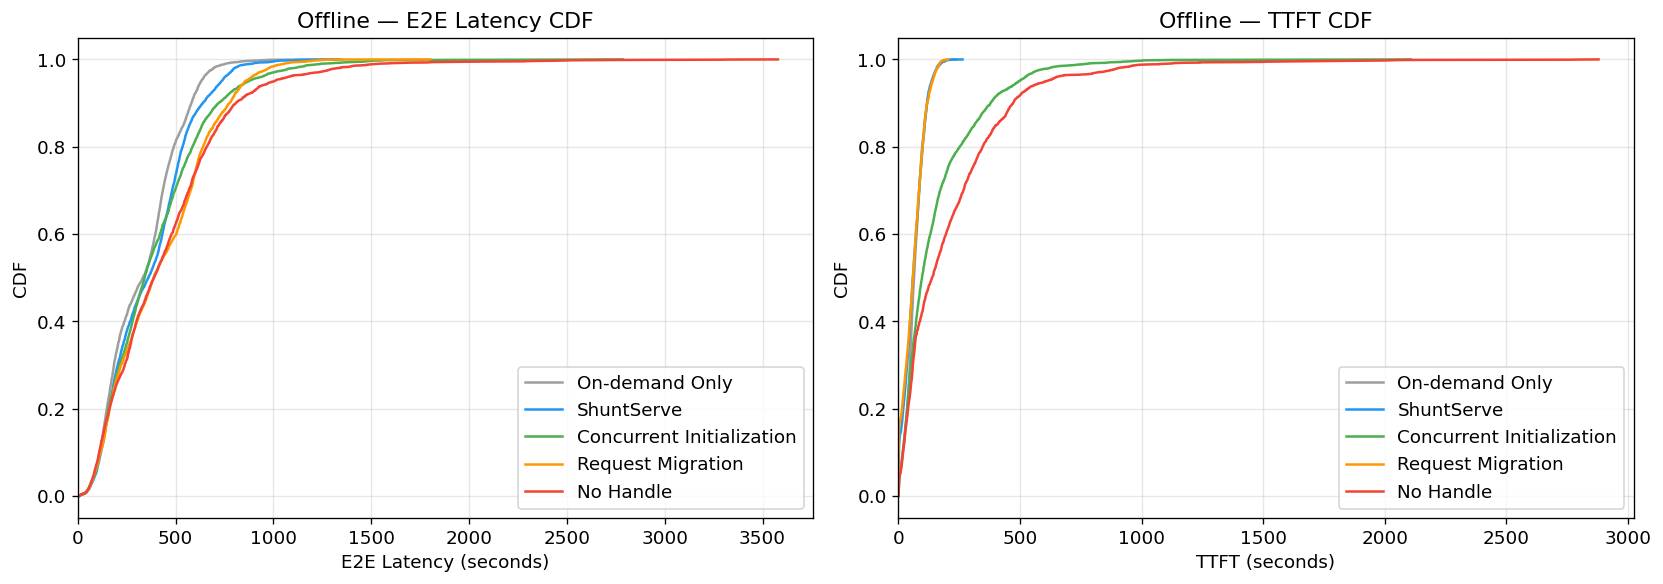

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in SYSTEMS:
    df = offline_traces[name]
    sorted_lat = np.sort(df["Latency"].values)
    cdf = np.arange(1, len(sorted_lat) + 1) / len(sorted_lat)
    axes[0].plot(sorted_lat, cdf, label=DISPLAY_NAMES[name], color=COLORS[name], linewidth=1.5)

axes[0].set_xlabel("E2E Latency (seconds)")
axes[0].set_ylabel("CDF")
axes[0].set_title("Offline — E2E Latency CDF")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0)

for name in SYSTEMS:
    df = offline_traces[name]
    sorted_ttft = np.sort(df["TTFT"].values)
    cdf = np.arange(1, len(sorted_ttft) + 1) / len(sorted_ttft)
    axes[1].plot(sorted_ttft, cdf, label=DISPLAY_NAMES[name], color=COLORS[name], linewidth=1.5)

axes[1].set_xlabel("TTFT (seconds)")
axes[1].set_ylabel("CDF")
axes[1].set_title("Offline — TTFT CDF")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0)

plt.tight_layout()
plt.show()

## Offline SendCount Distribution (Migration Analysis)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, name in zip(axes, ["ShuntServe", "RequestMigration"]):
    df = offline_traces[name]
    counts = df["SendCount"].value_counts().sort_index()
    bars = ax.bar(counts.index.astype(str), counts.values,
                  color=COLORS[name], hatch=HATCHES[name], **BAR_KW)
    ax.bar_label(bars)
    ax.set_xlabel("SendCount (times sent)")
    ax.set_ylabel("Number of requests")
    ax.set_title(f"Offline — {DISPLAY_NAMES[name]} SendCount Distribution")

    total = len(df)
    migrated = (df["SendCount"] > 1).sum()
    ax.text(0.95, 0.95, f"Total: {total}\nMigrated: {migrated} ({migrated/total*100:.1f}%)",
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## Offline Same-Request CDF — Filtered by Common RequestIDs

In [29]:
# Find common RequestIDs across all systems
offline_common_ids = None
for name in SYSTEMS:
    ids = set(offline_traces[name]["RequestID"].values)
    offline_common_ids = ids if offline_common_ids is None else offline_common_ids & ids
print(f"Common across ALL systems (offline): {len(offline_common_ids)} requests")

offline_filtered = {}
for name in SYSTEMS:
    df = offline_traces[name]
    offline_filtered[name] = df[df["RequestID"].isin(offline_common_ids)].copy()
    print(f"  {name}: {len(offline_filtered[name])} requests after filtering")

Common across ALL systems (offline): 3423 requests
  OnlyOnDemand: 3423 requests after filtering
  ShuntServe: 3423 requests after filtering
  ConcurrentInit: 3423 requests after filtering
  RequestMigration: 3423 requests after filtering
  NoHandle: 3423 requests after filtering


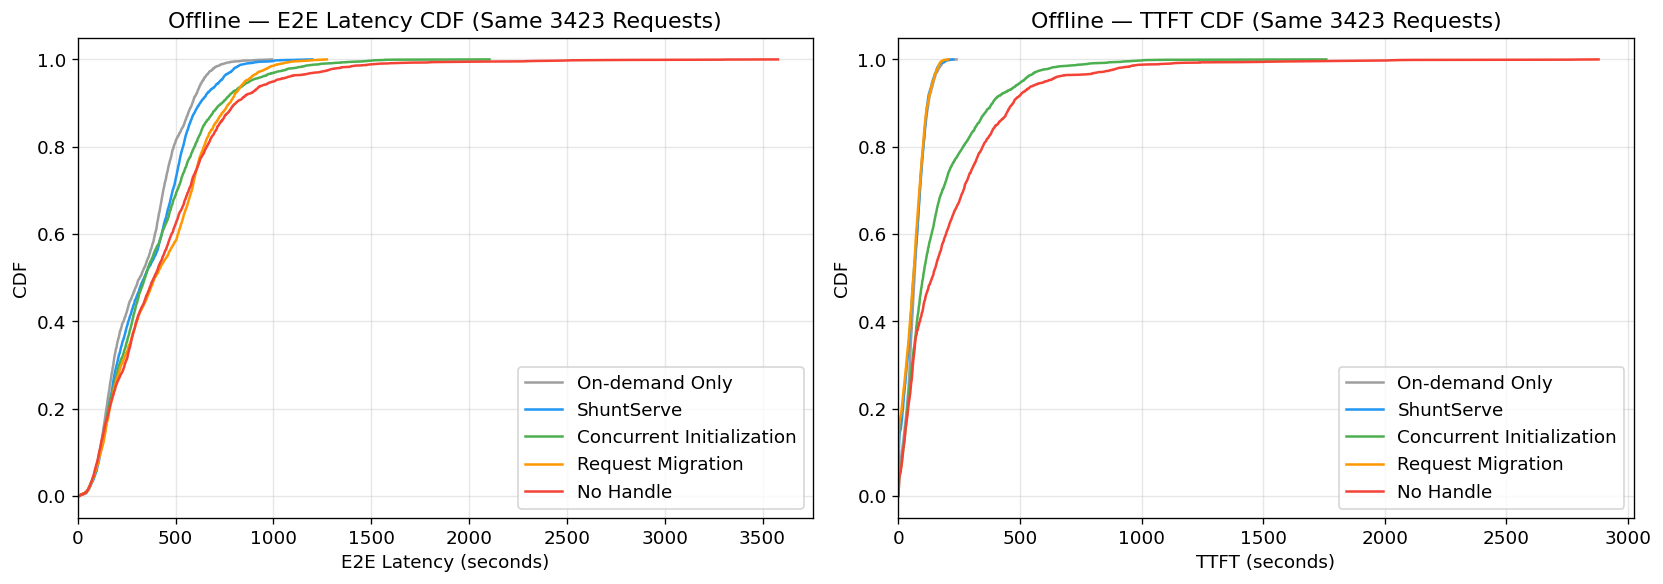

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in SYSTEMS:
    df = offline_filtered[name]
    sorted_lat = np.sort(df["Latency"].values)
    cdf = np.arange(1, len(sorted_lat) + 1) / len(sorted_lat)
    axes[0].plot(sorted_lat, cdf, label=DISPLAY_NAMES[name], color=COLORS[name], linewidth=1.5)

axes[0].set_xlabel("E2E Latency (seconds)")
axes[0].set_ylabel("CDF")
axes[0].set_title(f"Offline — E2E Latency CDF (Same {len(offline_common_ids)} Requests)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0)

for name in SYSTEMS:
    df = offline_filtered[name]
    sorted_ttft = np.sort(df["TTFT"].values)
    cdf = np.arange(1, len(sorted_ttft) + 1) / len(sorted_ttft)
    axes[1].plot(sorted_ttft, cdf, label=DISPLAY_NAMES[name], color=COLORS[name], linewidth=1.5)

axes[1].set_xlabel("TTFT (seconds)")
axes[1].set_ylabel("CDF")
axes[1].set_title(f"Offline — TTFT CDF (Same {len(offline_common_ids)} Requests)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0)

plt.tight_layout()
plt.show()

In [31]:
# Same-request summary statistics (offline)
print(f"Offline same-request comparison ({len(offline_common_ids)} common RequestIDs)")
print(f"{'System':28s} {'Mean E2E':>10s} {'P50 E2E':>10s} {'P99 E2E':>10s} {'Mean TTFT':>10s} {'P99 TTFT':>10s}")
for name in SYSTEMS:
    df = offline_filtered[name]
    print(f"{DISPLAY_NAMES[name]:28s} "
          f"{df['Latency'].mean():10.1f} "
          f"{df['Latency'].median():10.1f} "
          f"{df['Latency'].quantile(0.99):10.1f} "
          f"{df['TTFT'].mean():10.1f} "
          f"{df['TTFT'].quantile(0.99):10.1f}")

Offline same-request comparison (3423 common RequestIDs)
System                         Mean E2E    P50 E2E    P99 E2E  Mean TTFT   P99 TTFT
On-demand Only                    329.0      316.7      746.6       69.4      179.4
ShuntServe                        360.4      340.5      856.4       63.7      172.5
Concurrent Initialization         397.3      343.4     1245.4      160.7      780.5
Request Migration                 423.7      393.3     1038.1       61.7      168.9
No Handle                         447.6      390.3     1537.5      213.0     1100.3


## Offline Ablation Summary — 2×2 Matrix (Hot/Cold × Migration/Re-routing)

In [32]:
ablation = {
    ("Hot (switch_nodes)", "Migration"): "ShuntServe",
    ("Hot (switch_nodes)", "Re-routing"): "ConcurrentInit",
    ("Cold (stop+create)", "Migration"): "RequestMigration",
    ("Cold (stop+create)", "Re-routing"): "NoHandle",
}

rows = ["Hot (switch_nodes)", "Cold (stop+create)"]
cols = ["Migration", "Re-routing"]

print("=" * 90)
print(f"{'':25s} | {'Migration':30s} | {'Re-routing':30s}")
print("-" * 90)
for row in rows:
    cells = []
    for col in cols:
        s = ablation[(row, col)]
        dn = DISPLAY_NAMES[s]
        cell = f"{dn}\n  completed={offline_results[s]['completed']}\n  req/s={offline_results[s]['request_throughput']:.2f}\n  E2E={offline_results[s]['mean_e2el_ms']/1000:.1f}s\n  TTFT={offline_results[s]['mean_ttft_ms']/1000:.1f}s"
        cells.append(cell)
    lines_left = cells[0].split("\n")
    lines_right = cells[1].split("\n")
    max_lines = max(len(lines_left), len(lines_right))
    for i in range(max_lines):
        left = lines_left[i] if i < len(lines_left) else ""
        right = lines_right[i] if i < len(lines_right) else ""
        prefix = row if i == 0 else ""
        print(f"{prefix:25s} | {left:30s} | {right:30s}")
    print("-" * 90)

# Normalized comparison table (baseline = OnlyOnDemand)
print(f"\n\nNormalized to {DISPLAY_NAMES['OnlyOnDemand']} (baseline = 1.00):")
print(f"{'System':28s} {'Completed':>10s} {'Req/s':>10s} {'E2E':>10s} {'TTFT':>10s}")
base = offline_results["OnlyOnDemand"]
for name in SYSTEMS:
    r = offline_results[name]
    print(f"{DISPLAY_NAMES[name]:28s} "
          f"{r['completed']/base['completed']:10.2f} "
          f"{r['request_throughput']/base['request_throughput']:10.2f} "
          f"{r['mean_e2el_ms']/base['mean_e2el_ms']:10.2f} "
          f"{r['mean_ttft_ms']/base['mean_ttft_ms']:10.2f}")

                          | Migration                      | Re-routing                    
------------------------------------------------------------------------------------------
Hot (switch_nodes)        | ShuntServe                     | Concurrent Initialization     
                          |   completed=4295               |   completed=3968              
                          |   req/s=1.19                   |   req/s=1.10                  
                          |   E2E=365.5s                   |   E2E=394.0s                  
                          |   TTFT=62.3s                   |   TTFT=155.8s                 
------------------------------------------------------------------------------------------
Cold (stop+create)        | Request Migration              | No Handle                     
                          |   completed=3691               |   completed=3429              
                          |   req/s=1.03                   |   req/s=0.95         

---
# Part II: Online Analysis
## Load Online JSON Results

In [33]:
ONLINE_DIR = "online/scenario_A"

online_json_files = {
    "OnlyOnDemand": "online_only_ondemand.json",
    "ShuntServe": "online_shuntserve.json",
    "ConcurrentInit": "online_concurrent_initialization.json",
    "RequestMigration": "online_request_migration.json",
    "NoHandle": "online_no_handle.json",
}

online_results = {}
for name, fname in online_json_files.items():
    with open(f"{ONLINE_DIR}/{fname}") as f:
        online_results[name] = json.load(f)

df_online = pd.DataFrame([
    {"system": name, **{k: v for k, v in data.items() if not isinstance(v, (dict, list))}}
    for name, data in online_results.items()
]).set_index("system")

df_online[["completed", "request_throughput", "output_throughput", "total_token_throughput",
           "mean_ttft_ms", "median_ttft_ms", "mean_tpot_ms", "mean_e2el_ms", "benchmark_duration"]]

,completed,request_throughput,output_throughput,total_token_throughput,mean_ttft_ms,median_ttft_ms,mean_tpot_ms,mean_e2el_ms,benchmark_duration
system,,,,,,,,,
OnlyOnDemand,2494,0.692699,193.750675,780.286821,1661.452877,1492.017031,382.660408,109337.602790,3600.410673
ShuntServe,2500,0.694365,194.183650,782.321738,2109.815125,1549.526930,399.928393,115071.428572,3600.411265
ConcurrentInitialization,2494,0.692697,193.755830,780.344092,16525.721529,1796.916962,389.390928,126090.662002,3600.418108
RequestMigration,2495,0.692975,193.679347,780.838064,12322.951738,1780.549049,535.453017,153735.863102,3600.420022
NoHandle,2494,0.692696,193.564512,779.705458,27278.597647,2095.486164,500.485823,160749.802331,3600.427536


## Online Latency Comparison (TTFT / TPOT / E2E)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

x = np.arange(len(SYSTEMS))
w = 0.35
display_labels = [DISPLAY_NAMES[s] for s in SYSTEMS]

# TTFT
metrics = ["mean_ttft_ms", "median_ttft_ms"]
labels = ["Mean", "Median"]
for i, (m, label) in enumerate(zip(metrics, labels)):
    vals = [online_results[s][m] / 1000 for s in SYSTEMS]
    bars = []
    for j, s in enumerate(SYSTEMS):
        bar = axes[0].bar(j + i * w - w/2, vals[j], w, color=COLORS[s], hatch=HATCHES[s], **BAR_KW)
        bars.append(bar)
axes[0].set_title("TTFT (Time to First Token)")
axes[0].set_ylabel("seconds")
axes[0].set_xticks(x)
axes[0].set_xticklabels(display_labels, rotation=25, ha='right')

# TPOT
metrics = ["mean_tpot_ms", "median_tpot_ms"]
for i, (m, label) in enumerate(zip(metrics, labels)):
    vals = [online_results[s][m] for s in SYSTEMS]
    for j, s in enumerate(SYSTEMS):
        axes[1].bar(j + i * w - w/2, vals[j], w, color=COLORS[s], hatch=HATCHES[s], **BAR_KW)
axes[1].set_title("TPOT (Time per Output Token)")
axes[1].set_ylabel("ms")
axes[1].set_xticks(x)
axes[1].set_xticklabels(display_labels, rotation=25, ha='right')

# E2E
metrics = ["mean_e2el_ms", "median_e2el_ms"]
for i, (m, label) in enumerate(zip(metrics, labels)):
    vals = [online_results[s][m] / 1000 for s in SYSTEMS]
    for j, s in enumerate(SYSTEMS):
        axes[2].bar(j + i * w - w/2, vals[j], w, color=COLORS[s], hatch=HATCHES[s], **BAR_KW)
axes[2].set_title("E2E Latency")
axes[2].set_ylabel("seconds")
axes[2].set_xticks(x)
axes[2].set_xticklabels(display_labels, rotation=25, ha='right')

plt.tight_layout()
plt.show()

## Load Online CSV Traces

In [35]:
ONLINE_TRACE_DIR = f"{ONLINE_DIR}/Trace"
online_csv_files = {
    "OnlyOnDemand": sorted(glob.glob(f"{ONLINE_TRACE_DIR}/spottolerance_online_only_ondemand_*.csv"))[-1],
    "ShuntServe": sorted(glob.glob(f"{ONLINE_TRACE_DIR}/spottolerance_online_shuntserve_*.csv"))[-1],
    "ConcurrentInit": sorted(glob.glob(f"{ONLINE_TRACE_DIR}/spottolerance_online_concurrent_initialization_*.csv"))[-1],
    "RequestMigration": sorted(glob.glob(f"{ONLINE_TRACE_DIR}/spottolerance_online_request_migration_*.csv"))[-1],
    "NoHandle": sorted(glob.glob(f"{ONLINE_TRACE_DIR}/spottolerance_online_no_handle_*.csv"))[-1],
}

online_traces = {}
for name, path in online_csv_files.items():
    df = pd.read_csv(path)
    df["system"] = name
    t0 = df["ArrivalTime"].min()
    df["arrival_min"] = (df["ArrivalTime"] - t0) / 60
    df["completion_min"] = (df["CompletionTime"] - t0) / 60
    online_traces[name] = df
    print(f"{name}: {len(df)} requests, {path.split('/')[-1]}")

OnlyOnDemand: 2494 requests, spottolerance_online_only_ondemand_llama3_70b_scenario_A_20260323_2320.csv
ShuntServe: 2500 requests, spottolerance_online_shuntserve_scenario_A_20260323_1157.csv
ConcurrentInit: 2494 requests, spottolerance_online_concurrent_initialization_llama3_70b_scenario_A_20260323_1354.csv
RequestMigration: 2495 requests, spottolerance_online_request_migration_llama3_70b_scenario_A_20260323_2218.csv
NoHandle: 2494 requests, spottolerance_online_no_handle_llama3_70b_scenario_A_20260323_1054.csv


## Online Throughput Timeline (centered 10-min moving average)

In [ ]:
# --- Online Throughput Timeline (paper-ready, centered moving average) ---
window_size = 600
duration = DURATION_SEC
stride = 60
fs = 20

# Calculate RPS for each system
online_rps = {}
online_times_rps = {}
for name in SYSTEMS:
    t, rps = calculate_rps_with_moving_average(online_traces[name], window=window_size, max_time=duration)
    online_times_rps[name] = t
    online_rps[name] = rps

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

plot_order = ["OnlyOnDemand", "NoHandle", "RequestMigration", "ConcurrentInit", "ShuntServe"]
max_rps = 0
min_rps = float('inf')

for name in plot_order:
    if name not in online_rps:
        continue
    t = online_times_rps[name][::stride]
    rps = online_rps[name][::stride]
    max_rps = max(max_rps, np.max(online_rps[name]))
    min_rps = min(min_rps, np.min(online_rps[name]))

    ax.plot(t, rps, label=DISPLAY_NAMES[name], color=COLORS[name], linewidth=3, alpha=0.8)

    # Average dashed line
    avg_rps = np.mean(online_rps[name])
    ax.axhline(y=avg_rps, color=COLORS[name], linestyle='--', linewidth=3, alpha=0.6, dashes=(5, 7))

ax.set_xlabel('Time (seconds)', fontsize=fs)
ax.set_ylabel('Requests Per Second (RPS)', fontsize=fs)
ax.set_ylim(min_rps, max_rps * 1.05)
ax.tick_params(axis='both', labelsize=fs)
plt.tight_layout()
plt.savefig("../figures/llama3_70b_scenario_A_online_throughput_timeline.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Print summary
for name in plot_order:
    if name in online_rps:
        print(f"{DISPLAY_NAMES[name]:28s} — Avg RPS: {np.mean(online_rps[name]):.2f}, Peak: {np.max(online_rps[name]):.2f}")

## Online Latency Timeline (centered 10-min moving average, median)

In [ ]:
# --- Online Latency Timeline (paper-ready, centered moving average) ---
LATENCY_WINDOW_SEC = 600
stride = 60
fs = 20

plot_order = ["OnlyOnDemand", "NoHandle", "RequestMigration", "ConcurrentInit", "ShuntServe"]

for metric, ylabel, fname in [
    ("Latency", "E2E Latency (seconds)", "../figures/llama3_70b_scenario_A_online_e2e_timeline.pdf"),
    ("TTFT", "TTFT (seconds)", "../figures/llama3_70b_scenario_A_online_ttft_timeline.pdf"),
]:
    fig, ax = plt.subplots(figsize=(10, 5))
    max_val = 0
    min_val = float('inf')

    for name in plot_order:
        df = online_traces[name]
        t0 = df["ArrivalTime"].min()
        arrivals = (df["ArrivalTime"] - t0).values
        latencies = df[metric].values

        sort_idx = np.argsort(arrivals)
        arrivals = arrivals[sort_idx]
        latencies = latencies[sort_idx]

        window_half = LATENCY_WINDOW_SEC // 2
        time_points = np.arange(0, DURATION_SEC + 1)
        medians = []
        for t in time_points:
            w_start = max(0, t - window_half)
            w_end = t + window_half + 1
            mask = (arrivals >= w_start) & (arrivals < w_end)
            if mask.sum() > 0:
                medians.append(np.median(latencies[mask]))
            else:
                medians.append(np.nan)
        medians = np.array(medians)

        t_plot = time_points[::stride]
        m_plot = medians[::stride]
        valid = ~np.isnan(m_plot)
        max_val = max(max_val, np.nanmax(medians))
        min_val = min(min_val, np.nanmin(medians))

        ax.plot(t_plot[valid], m_plot[valid], label=DISPLAY_NAMES[name],
                color=COLORS[name], linewidth=3, alpha=0.8)

    ax.set_xlabel('Time (seconds)', fontsize=fs)
    ax.set_ylabel(ylabel, fontsize=fs)
    ax.set_ylim(min_val * 0.9, max_val * 1.05)
    ax.tick_params(axis='both', labelsize=fs)
    plt.tight_layout()
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()

## Online CDF — E2E Latency & TTFT

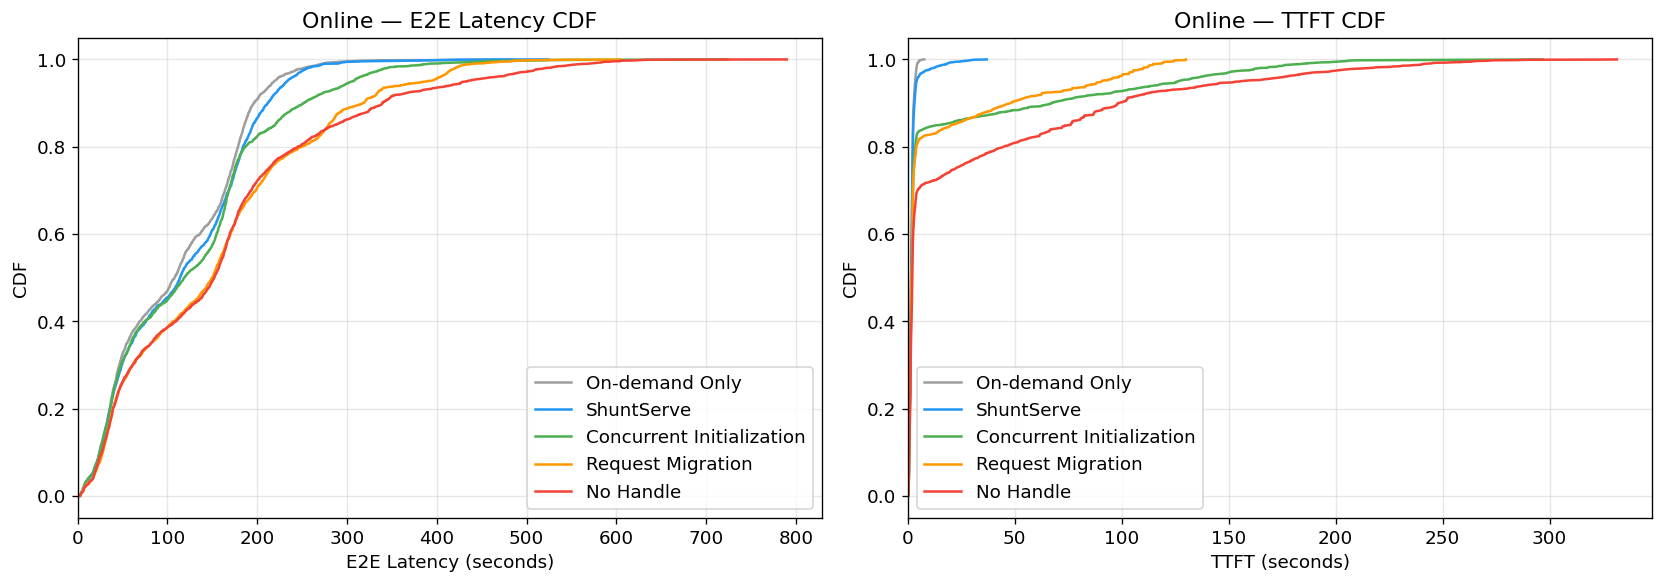

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in SYSTEMS:
    df = online_traces[name]
    sorted_lat = np.sort(df["Latency"].values)
    cdf = np.arange(1, len(sorted_lat) + 1) / len(sorted_lat)
    axes[0].plot(sorted_lat, cdf, label=DISPLAY_NAMES[name], color=COLORS[name], linewidth=1.5)

axes[0].set_xlabel("E2E Latency (seconds)")
axes[0].set_ylabel("CDF")
axes[0].set_title("Online — E2E Latency CDF")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0)

for name in SYSTEMS:
    df = online_traces[name]
    sorted_ttft = np.sort(df["TTFT"].values)
    cdf = np.arange(1, len(sorted_ttft) + 1) / len(sorted_ttft)
    axes[1].plot(sorted_ttft, cdf, label=DISPLAY_NAMES[name], color=COLORS[name], linewidth=1.5)

axes[1].set_xlabel("TTFT (seconds)")
axes[1].set_ylabel("CDF")
axes[1].set_title("Online — TTFT CDF")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0)

plt.tight_layout()
plt.show()

## Online SendCount Distribution (Migration Analysis)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, name in zip(axes, ["ShuntServe", "RequestMigration"]):
    df = online_traces[name]
    counts = df["SendCount"].value_counts().sort_index()
    bars = ax.bar(counts.index.astype(str), counts.values,
                  color=COLORS[name], hatch=HATCHES[name], **BAR_KW)
    ax.bar_label(bars)
    ax.set_xlabel("SendCount (times sent)")
    ax.set_ylabel("Number of requests")
    ax.set_title(f"Online — {DISPLAY_NAMES[name]} SendCount Distribution")

    total = len(df)
    migrated = (df["SendCount"] > 1).sum()
    ax.text(0.95, 0.95, f"Total: {total}\nMigrated: {migrated} ({migrated/total*100:.1f}%)",
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## Online Same-Request CDF & Summary Stats

In [39]:
# Find common RequestIDs across all systems (online)
online_common_ids = None
for name in SYSTEMS:
    ids = set(online_traces[name]["RequestID"].values)
    online_common_ids = ids if online_common_ids is None else online_common_ids & ids
print(f"Common across ALL systems (online): {len(online_common_ids)} requests")

online_filtered = {}
for name in SYSTEMS:
    df = online_traces[name]
    online_filtered[name] = df[df["RequestID"].isin(online_common_ids)].copy()
    print(f"  {name}: {len(online_filtered[name])} requests after filtering")

Common across ALL systems (online): 2487 requests
  OnlyOnDemand: 2487 requests after filtering
  ShuntServe: 2487 requests after filtering
  ConcurrentInit: 2487 requests after filtering
  RequestMigration: 2487 requests after filtering
  NoHandle: 2487 requests after filtering


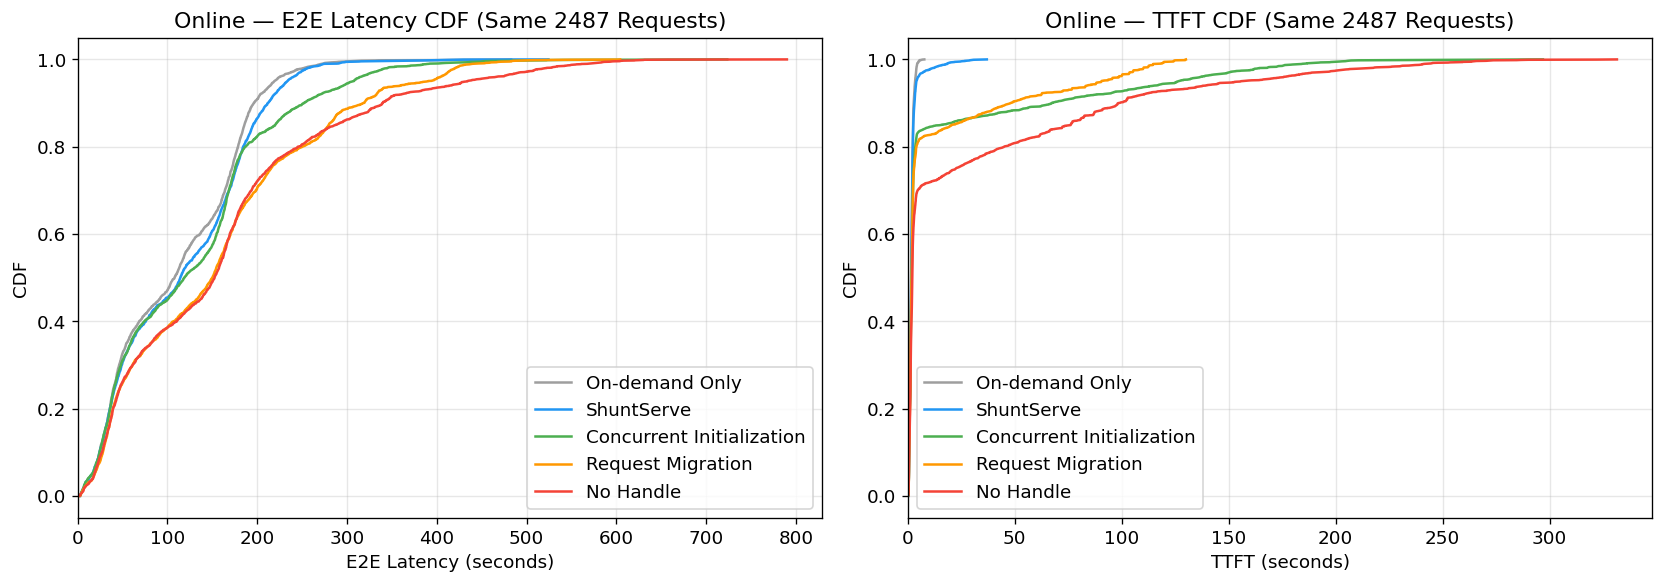

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in SYSTEMS:
    df = online_filtered[name]
    sorted_lat = np.sort(df["Latency"].values)
    cdf = np.arange(1, len(sorted_lat) + 1) / len(sorted_lat)
    axes[0].plot(sorted_lat, cdf, label=DISPLAY_NAMES[name], color=COLORS[name], linewidth=1.5)

axes[0].set_xlabel("E2E Latency (seconds)")
axes[0].set_ylabel("CDF")
axes[0].set_title(f"Online — E2E Latency CDF (Same {len(online_common_ids)} Requests)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0)

for name in SYSTEMS:
    df = online_filtered[name]
    sorted_ttft = np.sort(df["TTFT"].values)
    cdf = np.arange(1, len(sorted_ttft) + 1) / len(sorted_ttft)
    axes[1].plot(sorted_ttft, cdf, label=DISPLAY_NAMES[name], color=COLORS[name], linewidth=1.5)

axes[1].set_xlabel("TTFT (seconds)")
axes[1].set_ylabel("CDF")
axes[1].set_title(f"Online — TTFT CDF (Same {len(online_common_ids)} Requests)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0)

plt.tight_layout()
plt.show()

In [41]:
# Same-request summary statistics (online)
print(f"Online same-request comparison ({len(online_common_ids)} common RequestIDs)")
print(f"{'System':28s} {'Mean E2E':>10s} {'P50 E2E':>10s} {'P99 E2E':>10s} {'Mean TTFT':>10s} {'P99 TTFT':>10s}")
for name in SYSTEMS:
    df = online_filtered[name]
    print(f"{DISPLAY_NAMES[name]:28s} "
          f"{df['Latency'].mean():10.1f} "
          f"{df['Latency'].median():10.1f} "
          f"{df['Latency'].quantile(0.99):10.1f} "
          f"{df['TTFT'].mean():10.1f} "
          f"{df['TTFT'].quantile(0.99):10.1f}")

Online same-request comparison (2487 common RequestIDs)
System                         Mean E2E    P50 E2E    P99 E2E  Mean TTFT   P99 TTFT
On-demand Only                    109.3      107.9      272.0        1.7        4.4
ShuntServe                        115.2      114.3      276.9        2.1       18.5
Concurrent Initialization         126.1      118.7      391.4       16.6      184.5
Request Migration                 153.9      150.0      440.3       12.4      116.8
No Handle                         161.0      152.4      567.8       27.3      241.9


## Online Ablation Summary — 2×2 Matrix (Hot/Cold × Migration/Re-routing)

In [42]:
ablation_online = {
    ("Hot (switch_nodes)", "Migration"): "ShuntServe",
    ("Hot (switch_nodes)", "Re-routing"): "ConcurrentInit",
    ("Cold (stop+create)", "Migration"): "RequestMigration",
    ("Cold (stop+create)", "Re-routing"): "NoHandle",
}

rows = ["Hot (switch_nodes)", "Cold (stop+create)"]
cols = ["Migration", "Re-routing"]

print("=" * 90)
print(f"{'':25s} | {'Migration':30s} | {'Re-routing':30s}")
print("-" * 90)
for row in rows:
    cells = []
    for col in cols:
        s = ablation_online[(row, col)]
        dn = DISPLAY_NAMES[s]
        cell = f"{dn}\n  completed={online_results[s]['completed']}\n  req/s={online_results[s]['request_throughput']:.2f}\n  E2E={online_results[s]['mean_e2el_ms']/1000:.1f}s\n  TTFT={online_results[s]['mean_ttft_ms']/1000:.1f}s"
        cells.append(cell)
    lines_left = cells[0].split("\n")
    lines_right = cells[1].split("\n")
    max_lines = max(len(lines_left), len(lines_right))
    for i in range(max_lines):
        left = lines_left[i] if i < len(lines_left) else ""
        right = lines_right[i] if i < len(lines_right) else ""
        prefix = row if i == 0 else ""
        print(f"{prefix:25s} | {left:30s} | {right:30s}")
    print("-" * 90)

# Normalized comparison table (baseline = OnlyOnDemand)
print(f"\n\nNormalized to {DISPLAY_NAMES['OnlyOnDemand']} (baseline = 1.00):")
print(f"{'System':28s} {'Completed':>10s} {'Req/s':>10s} {'E2E':>10s} {'TTFT':>10s}")
base = online_results["OnlyOnDemand"]
for name in SYSTEMS:
    r = online_results[name]
    print(f"{DISPLAY_NAMES[name]:28s} "
          f"{r['completed']/base['completed']:10.2f} "
          f"{r['request_throughput']/base['request_throughput']:10.2f} "
          f"{r['mean_e2el_ms']/base['mean_e2el_ms']:10.2f} "
          f"{r['mean_ttft_ms']/base['mean_ttft_ms']:10.2f}")

                          | Migration                      | Re-routing                    
------------------------------------------------------------------------------------------
Hot (switch_nodes)        | ShuntServe                     | Concurrent Initialization     
                          |   completed=2500               |   completed=2494              
                          |   req/s=0.69                   |   req/s=0.69                  
                          |   E2E=115.1s                   |   E2E=126.1s                  
                          |   TTFT=2.1s                    |   TTFT=16.5s                  
------------------------------------------------------------------------------------------
Cold (stop+create)        | Request Migration              | No Handle                     
                          |   completed=2495               |   completed=2494              
                          |   req/s=0.69                   |   req/s=0.69         